In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

In [2]:
listings_df_raw = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("multiLine", "true") \
    .load("../data/Listings.csv")
    # .load("hdfs://master-node:9000/AirbnbData/Listings.csv")  # dùng khi master-node bật
listings_df_raw.show(truncate=False)

+----------+---------------------------------------------------+--------+----------+----------------------------+------------------+------------------+--------------------+-----------------+-------------------------+--------------------+----------------------+-------------------+--------+-----+--------+---------+----------------+------------+------------+--------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+--------------+--------------+--------------------+----------------------+-------------------------+---------------------+---------------------------+----------------------+-------------------+----------------+
|listing_id|na

In [3]:
from pyspark.sql.functions import col, from_json
from pyspark.sql.types import ArrayType, StringType
listings_df = listings_df_raw.withColumn(
    "amenities",
    from_json(col("amenities"), ArrayType(StringType()))
)

In [4]:
from pyspark.sql.functions import when, col
# Quy đổi toàn bộ giá từ tiền tệ địa phương (Local Currency) sang USD
# Tỷ giá được cập nhật theo thời điểm hiện tại
listings_df_currency = listings_df.withColumn(
    "price_usd",
    when(col("city") == "New York", col("price") * 1.0)           # USD giữ nguyên
    .when(col("city") == "Paris", col("price") * 1.156)            # EUR -> USD
    .when(col("city") == "Rome", col("price") * 1.156)             # EUR -> USD
    .when(col("city") == "Sydney", col("price") * 0.7038)           # AUD -> USD
    .when(col("city") == "Hong Kong", col("price") * 0.1276)        # HKD -> USD
    .when(col("city") == "Bangkok", col("price") * 0.03048)         # THB -> USD
    .when(col("city") == "Mexico City", col("price") * 0.05795)     # MXN -> USD
    .when(col("city") == "Cape Town", col("price") * 0.06130)       # ZAR -> USD
    .when(col("city") == "Istanbul", col("price") *  0.02162)        # TRY -> USD
    .when(col("city") == "Rio de Janeiro", col("price") * 0.1961 )   # BRL -> USD
    .otherwise(col("price"))
)

In [5]:
reviews_df=spark.read.csv("../data/Reviews.csv",header=True,inferSchema=True)
# reviews_df=spark.read.csv("hdfs://master-node:9000/AirbnbData/Reviews.csv",header=True,inferSchema=True)  # dùng khi master-node bật
reviews_df.show()

+----------+---------+----------+-----------+
|listing_id|review_id|      date|reviewer_id|
+----------+---------+----------+-----------+
|     11798|330265172|2018-09-30|   11863072|
|     15383|330103585|2018-09-30|   39147453|
|     16455|329985788|2018-09-30|    1125378|
|     17919|330016899|2018-09-30|  172717984|
|     26827|329995638|2018-09-30|   17542859|
|     74561|330089224|2018-09-30|  173044789|
|    140355|330194958|2018-09-30|  160093807|
|    162163|329980859|2018-09-30|   94026758|
|    167998|329950677|2018-09-30|   35388162|
|    178188|330213008|2018-09-30|    3652511|
|    232956|330140226|2018-09-30|   57664145|
|    266725|330038354|2018-09-30|   77387165|
|    314288|330299075|2018-09-30|  192717587|
|    325880|330081449|2018-09-30|  154527568|
|    335003|329968377|2018-09-30|    3461699|
|    348747|330131287|2018-09-30|    9554201|
|    352851|330201364|2018-09-30|  142182690|
|    378714|330246144|2018-09-30|   15772951|
|    406852|330283854|2018-09-30| 

In [6]:
listings_df_currency.createOrReplaceTempView("listings")
reviews_df.createOrReplaceTempView("reviews")
spark.catalog.listTables()

[Table(name='listings', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True),
 Table(name='reviews', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True)]

In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler, Imputer
from pyspark.ml.classification import (
    LogisticRegression, DecisionTreeClassifier,
    RandomForestClassifier, LinearSVC
)
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
    ClusteringEvaluator
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"
from sklearn.preprocessing import StandardScaler
from pyspark.sql.functions import col, regexp_replace
from pyspark.sql.types import DoubleType
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from pyspark.ml.functions import vector_to_array
from sklearn.metrics import confusion_matrix
import numpy as np

print("Import thư viện thành công.")

Import thư viện thành công.


In [8]:
# ── Đặc trưng số (Numeric Features) ──────────────────────────────────────────
NUMERIC_COLS = [
    "price_usd",
    "host_total_listings_count",
    "minimum_nights",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_communication",
]

# ── Đặc trưng phân loại (Categorical Features) ───────────────────────────────
CATEGORICAL_COLS = [
    "host_response_time",
    "instant_bookable",
    "host_identity_verified",
    "room_type",
]

# ── Cột mục tiêu ─────────────────────────────────────────────────────────────
TARGET_COL = "host_is_superhost"

print("Cấu hình hoàn tất.")
print(f"   Numeric   : {len(NUMERIC_COLS)} cột")
print(f"   Categoric : {len(CATEGORICAL_COLS)} cột")

Cấu hình hoàn tất.
   Numeric   : 6 cột
   Categoric : 4 cột


In [9]:
from pyspark.sql.functions import col, when, count, lit

# 1. Gán DataFrame và lọc bỏ dữ liệu thiếu
df = listings_df_currency.dropna(subset=[TARGET_COL, 'review_scores_rating'])

# 2. Tạo biến mục tiêu (Label Encoding)
df = df.withColumn("label", when(col(TARGET_COL) == "t", 1.0).otherwise(0.0))

# 3. Tính class_weight tối ưu (chỉ quét dữ liệu trên HDFS đúng 1 lần)
# Sử dụng groupBy kết hợp agg để tránh các lệnh .count() riêng lẻ
counts = df.groupBy("label").agg(count("*").alias("count")).collect()
counts_dict = {row["label"]: row["count"] for row in counts}

superhost_count = counts_dict.get(1.0, 0)
total_count = sum(counts_dict.values())
non_superhost_count = total_count - superhost_count

# Tránh lỗi chia cho 0 nếu dữ liệu thiếu class tương ứng
weight_positive = total_count / (2 * superhost_count) if superhost_count > 0 else 0
weight_negative = total_count / (2 * non_superhost_count) if non_superhost_count > 0 else 0

# Gán trọng số
df = df.withColumn(
    "class_weight",
    when(col("label") == 1.0, lit(weight_positive)).otherwise(lit(weight_negative))
)

print("Đã xử lý xong biến df! Sẵn sàng cho Phần 2.")

Đã xử lý xong biến df! Sẵn sàng cho Phần 2.


Tiền xử lý dữ liệu

In [10]:
def build_preprocessing_stages(with_scaling=False):
    """
    Tạo danh sách các bước tiền xử lý.
    - with_scaling=False: Dùng cho LR, DT, RF (tích hợp StandardScaler tùy chọn)
    - with_scaling=True : Bắt buộc dùng cho SVM
    """
    stages = []

    # Bước 1: Xử lý dữ liệu khuyết thiếu (Imputer)
    imputer = Imputer(
        inputCols=NUMERIC_COLS,
        outputCols=NUMERIC_COLS
    ).setStrategy("median")
    stages.append(imputer)

    # Bước 2: Mã hóa biến phân loại (StringIndexer)
    indexed_cat_cols = []
    for col_name in CATEGORICAL_COLS:
        out_col = f"{col_name}_indexed"
        indexer = StringIndexer(
            inputCol=col_name,
            outputCol=out_col,
            handleInvalid="keep"
        )
        stages.append(indexer)
        indexed_cat_cols.append(out_col)

    # Bước 3: Đóng gói đặc trưng (VectorAssembler)
    feature_cols = NUMERIC_COLS + indexed_cat_cols
    raw_output = "raw_features" if with_scaling else "features"
    assembler = VectorAssembler(
        inputCols=feature_cols,
        outputCol=raw_output
    )
    stages.append(assembler)

    # Bước 4 (Tuỳ chọn): Chuẩn hóa dữ liệu (StandardScaler)
    # Bắt buộc với SVM vì thuật toán tính khoảng cách rất nhạy với thang đo
    if with_scaling:
        scaler = StandardScaler(
            inputCol="raw_features",
            outputCol="features",
            withStd=True,
            withMean=True
        )
        stages.append(scaler)

    return stages, feature_cols

print(" Hàm build_preprocessing_stages() đã sẵn sàng.")
print(f"   Số đặc trưng số  : {len(NUMERIC_COLS)}")
print(f"   Số đặc trưng loại: {len(CATEGORICAL_COLS)}")
print(f"   Tổng chiều vector: {len(NUMERIC_COLS) + len(CATEGORICAL_COLS)}")

 Hàm build_preprocessing_stages() đã sẵn sàng.
   Số đặc trưng số  : 6
   Số đặc trưng loại: 4
   Tổng chiều vector: 10


Ép kiểu cho các dữ liệu số

In [11]:
print("Đang xử lý và ép kiểu dữ liệu...")

# 2. Ép kiểu toàn bộ các cột đặc trưng số về chuẩn DoubleType
for c in NUMERIC_COLS:
    df = df.withColumn(c, col(c).cast(DoubleType()))

# 3. Kiểm tra lại schema để chắc chắn đã thành số (Double)
print("Đã ép kiểu xong! Cấu trúc các cột số hiện tại:")
df.select(NUMERIC_COLS).printSchema()

Đang xử lý và ép kiểu dữ liệu...
Đã ép kiểu xong! Cấu trúc các cột số hiện tại:
root
 |-- price_usd: double (nullable = true)
 |-- host_total_listings_count: double (nullable = true)
 |-- minimum_nights: double (nullable = true)
 |-- review_scores_rating: double (nullable = true)
 |-- review_scores_cleanliness: double (nullable = true)
 |-- review_scores_communication: double (nullable = true)



Chia tập dữ liệu

In [12]:
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)
print(f"Số mẫu Train: {train_data.count()}, Số mẫu Test: {test_data.count()}")

Số mẫu Train: 150442, Số mẫu Test: 37757


Lưu tập dữ liệu

In [13]:
# Lưu ra HDFS
#train_data.write.parquet("hdfs://localhost:9000/data/train_data.parquet", mode="overwrite")
#test_data.write.parquet("hdfs://localhost:9000/data/test_data.parquet", mode="overwrite")

# Lưu vào Local
train_data.write.mode("overwrite").parquet("../data/train_data.parquet")
test_data.write.mode("overwrite").parquet("../data/test_data.parquet")

Hàm tính các chỉ số đánh giá mô hình và lưu vào hàm chung để nữa show ra theo bảng tổng hợp 4 mô hình

In [14]:
# 1. Khởi tạo danh sách lưu kết quả của tất cả các mô hình
results_summary = []

# 2. Định nghĩa lại hàm đánh giá (có thêm lệnh return)
def evaluate_model(predictions, model_name):
    """Đánh giá mô hình qua Accuracy, ROC-AUC, Precision và Recall."""
    from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

    # Tính ROC-AUC
    auc = BinaryClassificationEvaluator(
        labelCol="label", metricName="areaUnderROC"
    ).evaluate(predictions)

    # Khởi tạo bộ đánh giá đa lớp
    eval_multi = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

    # Tính các chỉ số
    acc = eval_multi.evaluate(predictions, {eval_multi.metricName: "accuracy"})
    precision = eval_multi.evaluate(predictions, {eval_multi.metricName: "precisionByLabel", eval_multi.metricLabel: 1.0})
    recall = eval_multi.evaluate(predictions, {eval_multi.metricName: "recallByLabel", eval_multi.metricLabel: 1.0})

    print(f" {'Mô hình':<22}: {model_name}")
    print(f" {'Accuracy':<22}: {acc*100:.2f}%")
    print(f" {'ROC-AUC':<22}: {auc:.4f}")
    print(f" {'Precision (Superhost)':<22}: {precision:.4f}")
    print(f" {'Recall (Superhost)':<22}: {recall:.4f}")

    # BỔ SUNG: Trả về kết quả (dạng Dictionary) để lưu vào bảng tổng hợp
    return {
        "Model": model_name,
        "Accuracy": acc,
        "ROC-AUC": auc,
        "Precision": precision,
        "Recall": recall
    }

print("Đã khởi tạo results_summary và cập nhật hàm đánh giá!")

Đã khởi tạo results_summary và cập nhật hàm đánh giá!


In [15]:
print("=" * 40)
print(" MÔ HÌNH 1: LOGISTIC REGRESSION (LR)")
print("=" * 40)

# Xây dựng Pipeline (không cần StandardScaler)
lr_stages, feature_cols = build_preprocessing_stages(with_scaling=False)
lr = LogisticRegression(featuresCol="features", labelCol="label", weightCol="class_weight", maxIter=10)
lr_stages.append(lr)

# Huấn luyện
lr_pipeline = Pipeline(stages=lr_stages)
lr_model = lr_pipeline.fit(train_data)
lr_predictions = lr_model.transform(test_data)

# Đánh giá
res_lr = evaluate_model(lr_predictions, "Logistic Regression")
results_summary.append(res_lr)

 MÔ HÌNH 1: LOGISTIC REGRESSION (LR)
 Mô hình               : Logistic Regression
 Accuracy              : 71.53%
 ROC-AUC               : 0.7883
 Precision (Superhost) : 0.4439
 Recall (Superhost)    : 0.7268


In [16]:
print("=" * 40)
print(" MÔ HÌNH 2: DECISION TREE (DT)")
print("=" * 40)

# Xây dựng Pipeline
dt_stages, _ = build_preprocessing_stages(with_scaling=False)
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    maxDepth=5,
    seed=42
)
dt_stages.append(dt)

# Huấn luyện
dt_pipeline = Pipeline(stages=dt_stages)
dt_model = dt_pipeline.fit(train_data)
dt_predictions = dt_model.transform(test_data)

# Đánh giá
res_dt = evaluate_model(dt_predictions, "Decision Tree")
results_summary.append(res_dt)

# [Bonus cho báo cáo] Trích xuất quy tắc cây (500 ký tự đầu)
print("\n SƠ ĐỒ QUY TẮC CÂY QUYẾT ĐỊNH (500 ký tự đầu):")
print(dt_model.stages[-1].toDebugString[:500] + "...")

 MÔ HÌNH 2: DECISION TREE (DT)
 Mô hình               : Decision Tree
 Accuracy              : 73.16%
 ROC-AUC               : 0.7627
 Precision (Superhost) : 0.4658
 Recall (Superhost)    : 0.7884

 SƠ ĐỒ QUY TẮC CÂY QUYẾT ĐỊNH (500 ký tự đầu):
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_78e059314897, depth=5, numNodes=29, numClasses=2, numFeatures=10
  If (feature 3 <= 93.5)
   If (feature 6 in {2.0,3.0,4.0})
    Predict: 0.0
   Else (feature 6 not in {2.0,3.0,4.0})
    If (feature 3 <= 89.5)
     Predict: 0.0
    Else (feature 3 > 89.5)
     If (feature 3 <= 91.5)
      Predict: 0.0
     Else (feature 3 > 91.5)
      If (feature 2 <= 2.5)
       Predict: 0.0
      Else (feature 2 > 2.5)
       Predict: 1.0
  Else (fea...


In [17]:
print("=" * 40)
print(" MÔ HÌNH 3: RANDOM FOREST (RF)")
print("=" * 40)

# Xây dựng Pipeline
rf_stages, rf_feature_cols = build_preprocessing_stages(with_scaling=False)
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    numTrees=50,
    maxDepth=5,
    seed=42
)
rf_stages.append(rf)

# Huấn luyện
rf_pipeline = Pipeline(stages=rf_stages)
rf_model = rf_pipeline.fit(train_data)
rf_predictions = rf_model.transform(test_data)

# Đánh giá
res_rf = evaluate_model(rf_predictions, "Random Forest")
results_summary.append(res_rf)

 MÔ HÌNH 3: RANDOM FOREST (RF)
 Mô hình               : Random Forest
 Accuracy              : 73.58%
 ROC-AUC               : 0.8252
 Precision (Superhost) : 0.4705
 Recall (Superhost)    : 0.7835


In [18]:
from pyspark.ml.feature import StandardScaler

print("=" * 40)
print(" MÔ HÌNH 4: SVM (LinearSVC)")
print("=" * 40)

# Xây dựng Pipeline
svm_stages, _ = build_preprocessing_stages(with_scaling=True)
svm = LinearSVC(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    maxIter=10
)
svm_stages.append(svm)

# Huấn luyện
svm_pipeline = Pipeline(stages=svm_stages)
svm_model = svm_pipeline.fit(train_data)
svm_predictions = svm_model.transform(test_data)

# Đánh giá
res_svm = evaluate_model(svm_predictions, "SVM (LinearSVC)")
results_summary.append(res_svm)

 MÔ HÌNH 4: SVM (LinearSVC)
 Mô hình               : SVM (LinearSVC)
 Accuracy              : 70.48%
 ROC-AUC               : 0.7803
 Precision (Superhost) : 0.4328
 Recall (Superhost)    : 0.7319


In [19]:
# Bảng so sánh toàn diện 4 mô hình
print("\n" + "=" * 60)
print("    BẢNG SO SÁNH 4 MÔ HÌNH")
print("=" * 60)

all_predictions = {
    "Logistic Regression": lr_predictions,
    "Decision Tree"       : dt_predictions,
    "Random Forest"       : rf_predictions,
    "SVM"                 : svm_predictions,
}

metrics_config = {
    "accuracy"         : "accuracy",
    "precision"        : "weightedPrecision",
    "recall"           : "weightedRecall",
    "f1"               : "f1",
}

full_results = []

for name, preds in all_predictions.items():
    row = {"Model": name}

    # Tính các chỉ số Multiclass
    for metric_name, metric_key in metrics_config.items():
        val = MulticlassClassificationEvaluator(
            labelCol="label",
            predictionCol="prediction",
            metricName=metric_key
        ).evaluate(preds)
        row[metric_name] = round(val, 4)

    # AUC-ROC
    auc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    ).evaluate(preds)
    row["auc"] = round(auc, 4)

    full_results.append(row)

# In bảng kết quả
print(f"{'Mô hình':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC-AUC':>10}")
print("-" * 75)
for r in full_results:
    print(f"{r['Model']:<22} {r['accuracy']:>10.4f} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1']:>10.4f} {r['auc']:>10.4f}")
print("=" * 75)


    BẢNG SO SÁNH 4 MÔ HÌNH
Mô hình                  Accuracy  Precision     Recall         F1    ROC-AUC
---------------------------------------------------------------------------
Logistic Regression        0.7153     0.7839     0.7153     0.7337     0.7883
Decision Tree              0.7316     0.8063     0.7316     0.7496     0.7627
Random Forest              0.7358     0.8067     0.7358     0.7532     0.8252
SVM                        0.7048     0.7810     0.7048     0.7245     0.7803


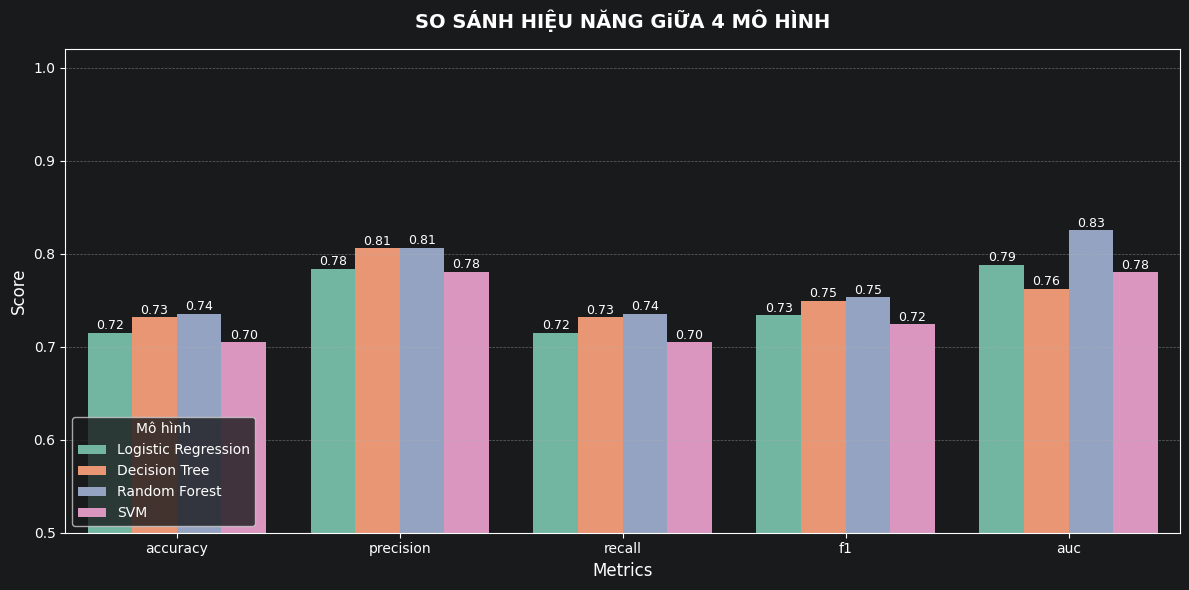

In [20]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuyển list kết quả của bạn thành DataFrame Pandas để dễ vẽ
df_plot = pd.DataFrame(full_results)

# 2. Xoay dọc bảng dữ liệu (Melt) để nạp vào Seaborn
df_melted = pd.melt(
    df_plot,
    id_vars=["Model"],
    var_name="Metric",
    value_name="Score"
)

# 3. Khởi tạo khung vẽ
plt.figure(figsize=(12, 6))

# 4. Vẽ biểu đồ cột nhóm
ax = sns.barplot(
    x="Metric",
    y="Score",
    hue="Model",
    data=df_melted,
    palette="Set2"
)

# Giới hạn trục Y từ 0.5 đến 1.0
# để thấy rõ sự chênh lệch nhỏ giữa các mô hình tốt
plt.ylim(0.5, 1.02)

plt.title("SO SÁNH HIỆU NĂNG GiỮA 4 MÔ HÌNH", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Metrics", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Mô hình", loc="lower left")

# Hiển thị số điểm cụ thể lên đầu mỗi cột cho dễ nhìn
for p in ax.patches:
    if p.get_height() > 0: # Chỉ hiển thị nếu cột có độ cao
        ax.annotate(f"{p.get_height():.2f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=9)

plt.tight_layout()
plt.show()


 CONFUSION MATRIX — RANDOM FOREST:
+----------------+-----+----+
|label_prediction|  0.0| 1.0|
+----------------+-----+----+
|             1.0| 1966|7116|
|             0.0|20666|8009|
+----------------+-----+----+



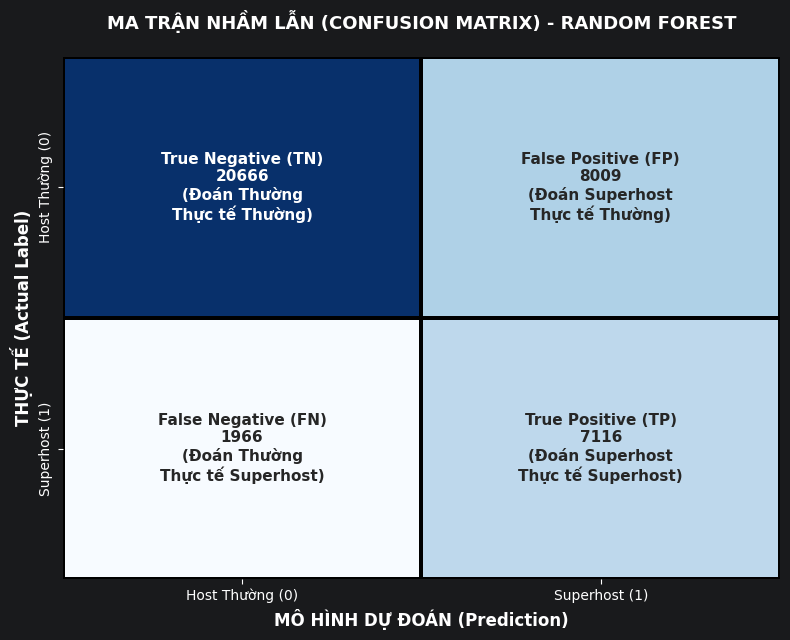

In [21]:
# Confusion Matrix — Random Forest
print("\n CONFUSION MATRIX — RANDOM FOREST:")
rf_predictions.crosstab("label", "prediction").show()
# 1. Chuyển đổi bảng crosstab của PySpark thành Pandas DataFrame để vẽ hình
# (Bảng crosstab của Spark mặc định trả về các cột đặt tên theo giá trị dự đoán)
matrix_df = rf_predictions.crosstab("label", "prediction").toPandas()

# Sắp xếp lại thứ tự hàng theo nhãn label (0 trước, 1 sau) để đúng chuẩn ma trận
matrix_df = matrix_df.sort_values(by="label_prediction").set_index("label_prediction")

# Đảm bảo các cột cũng theo thứ tự ['0.0', '1.0']
matrix_df = matrix_df[['0.0', '1.0']]

# 2. Trích xuất các giá trị để viết nhãn giải thích lên biểu đồ
tn = matrix_df.iloc[0, 0] # Dự đoán 0 - Thực tế 0
fp = matrix_df.iloc[0, 1] # Dự đoán 1 - Thực tế 0
fn = matrix_df.iloc[1, 0] # Dự đoán 0 - Thực tế 1
tp = matrix_df.iloc[1, 1] # Dự đoán 1 - Thực tế 1

# Tạo mảng văn bản để đè lên các ô vuông
labels = [
    [f"True Negative (TN)\n{tn}\n(Đoán Thường\nThực tế Thường)", f"False Positive (FP)\n{fp}\n(Đoán Superhost\nThực tế Thường)"],
    [f"False Negative (FN)\n{fn}\n(Đoán Thường\nThực tế Superhost)", f"True Positive (TP)\n{tp}\n(Đoán Superhost\nThực tế Superhost)"]
]

# 3. Tiến hành cấu hình và vẽ sơ đồ Heatmap
plt.figure(figsize=(8, 6.5))
sns.heatmap(
    matrix_df,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    annot_kws={"size": 11, "fontweight": "bold"},
    linewidths=1.5,
    linecolor="black"
)

# Định dạng các trục hiển thị
plt.title("MA TRẬN NHẦM LẪN (CONFUSION MATRIX) - RANDOM FOREST", fontsize=13, fontweight='bold', pad=20)
plt.xlabel("MÔ HÌNH DỰ ĐOÁN (Prediction)", fontsize=12, fontweight='bold')
plt.ylabel("THỰC TẾ (Actual Label)", fontsize=12, fontweight='bold')
plt.xticks([0.5, 1.5], ['Host Thường (0)', 'Superhost (1)'])
plt.yticks([0.5, 1.5], ['Host Thường (0)', 'Superhost (1)'], va="center")

plt.tight_layout()
plt.show()

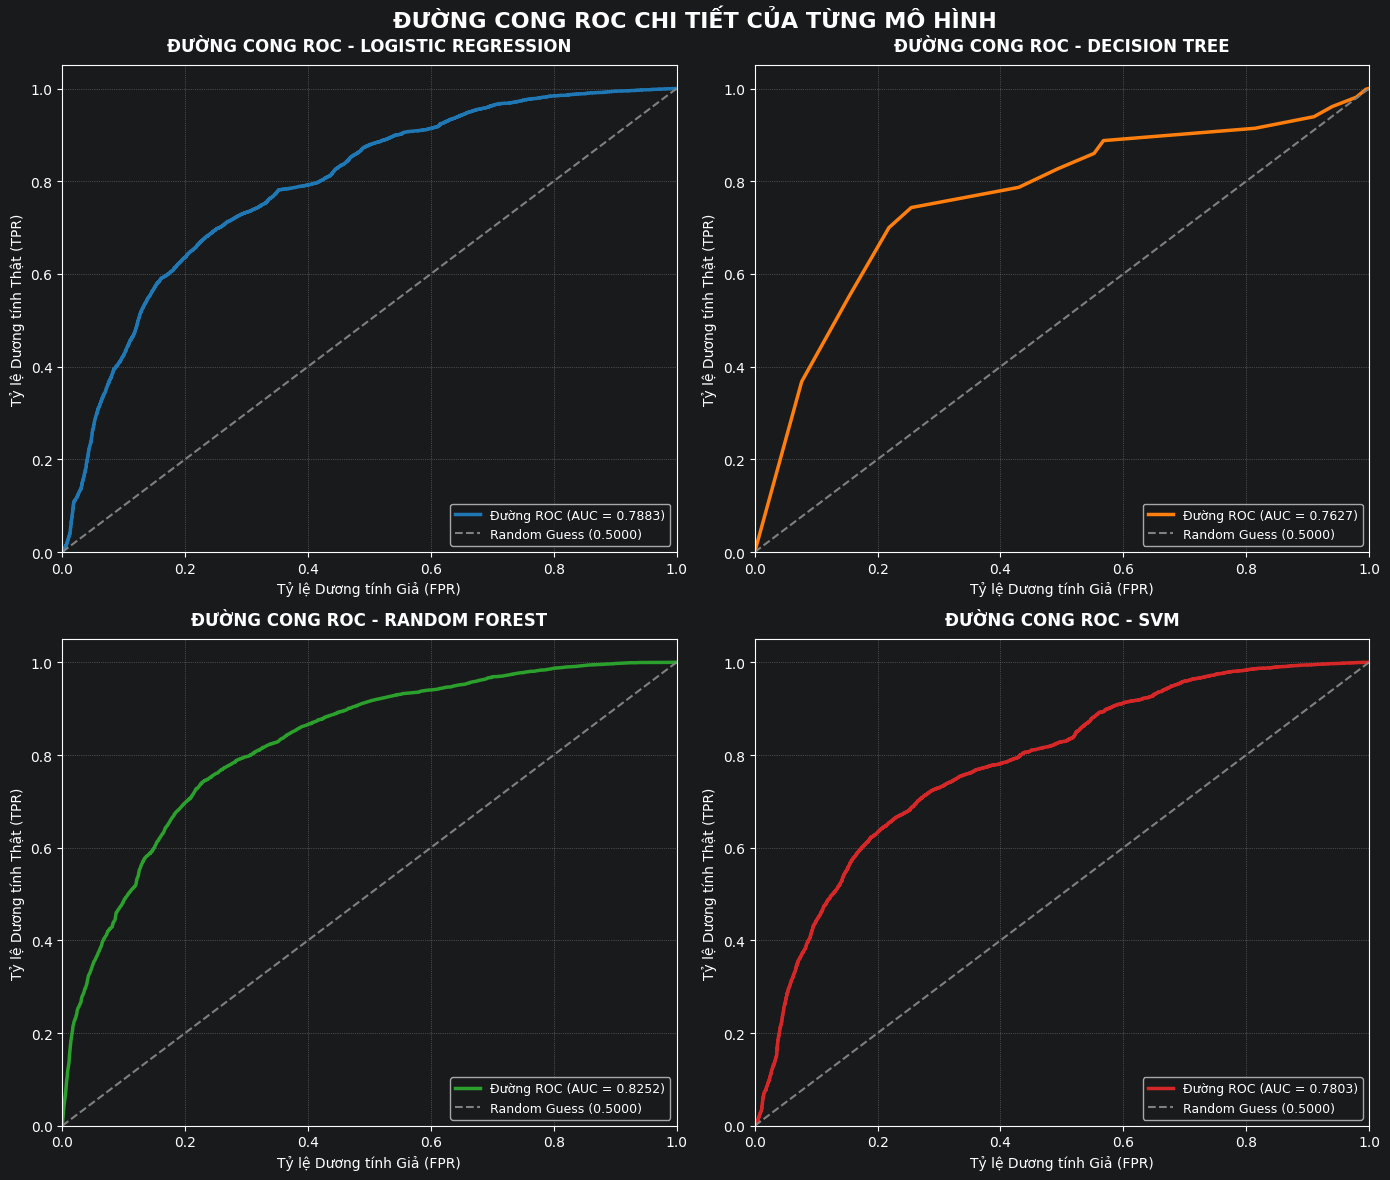

In [22]:
from sklearn.metrics import roc_curve, auc as auc

# 1. Khởi tạo khung lưới 2 hàng x 2 cột để chứa dữ liệu 4 mô hình
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel() # Phẳng hóa mảng 2D thành dạng danh sách [ax1, ax2, ax3, ax4] để dễ chạy vòng lặp

# Danh sách màu sắc phối riêng cho từng mô hình nhìn cho chuyên nghiệp
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# 2. Vòng lặp bóc tách dữ liệu và vẽ riêng từng ô đồ thị (subplot)
for i, (name, preds) in enumerate(all_predictions.items()):
    ax = axes[i] # Lấy ô đồ thị tương ứng

    # Trích xuất giá trị dự báo thô từ PySpark về Pandas
    df_scores = preds.withColumn("score", vector_to_array("rawPrediction")[1]) \
                     .select("label", "score").toPandas()

    # Tính toán chỉ số FPR, TPR và AUC-ROC bằng Scikit-learn
    fpr, tpr, _ = roc_curve(df_scores['label'], df_scores['score'])
    roc_auc = auc(fpr, tpr)

    # Vẽ đường cong ROC riêng của mô hình hiện tại
    ax.plot(fpr, tpr, color=colors[i], lw=2.5, label=f'Đường ROC (AUC = {roc_auc:.4f})')

    # VẼ ĐƯỜNG NÉT ĐỨT CHẠY QUA GIỮA (Đường cơ sở - Random Guess)
    ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (0.5000)')

    # Định dạng các chi tiết cho ô đồ thị này
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Tỷ lệ Dương tính Giả (FPR)', fontsize=10)
    ax.set_ylabel('Tỷ lệ Dương tính Thật (TPR)', fontsize=10)
    ax.set_title(f'ĐƯỜNG CONG ROC - {name.upper()}', fontsize=12, fontweight='bold', pad=10)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)

# 3. Căn chỉnh tổng thể khung hình
plt.suptitle('ĐƯỜNG CONG ROC CHI TIẾT CỦA TỪNG MÔ HÌNH', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


 BẢNG TẦM QUAN TRỌNG CỦA CÁC BIẾN (FEATURE IMPORTANCE):
---------------------------------------------
  review_scores_rating                0.5211  ████████████████████████████████████████████████████
  host_response_time_indexed          0.2661  ██████████████████████████
  review_scores_cleanliness           0.0948  █████████
  host_total_listings_count           0.0592  █████
  review_scores_communication         0.0436  ████
  host_identity_verified_indexed      0.0100  
  minimum_nights                      0.0026  
  instant_bookable_indexed            0.0021  
  price_usd                           0.0005  
  room_type_indexed                   0.0001  
---------------------------------------------
Đã lưu biểu đồ: feature_importance.png


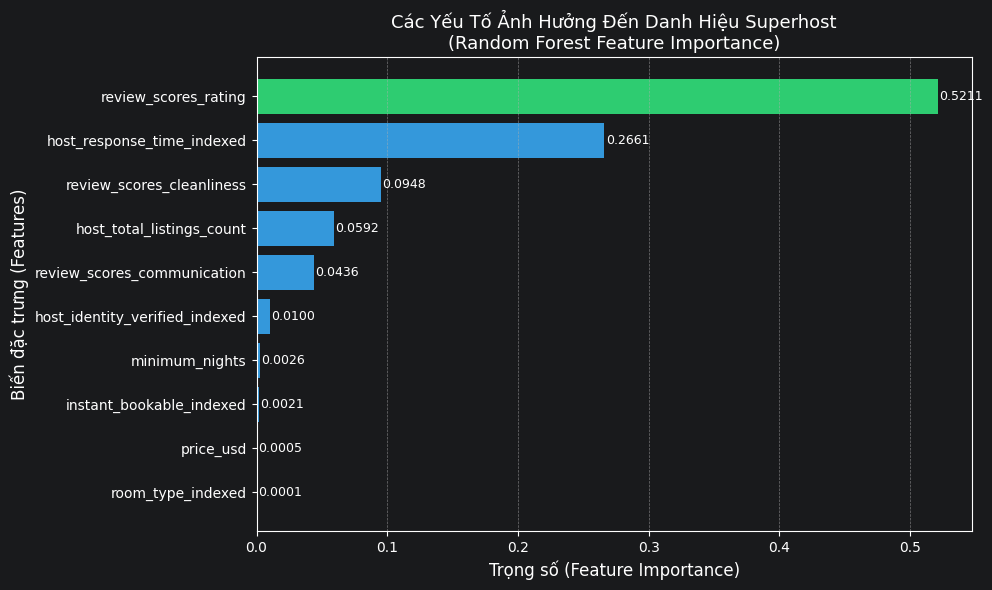


 ĐIỀU NHÓM NHẬN THẤY SAU KHI XEM:
   → Yếu tố dẫn dắt: 'review_scores_rating' (0.5211) và 'host_response_time_indexed' (0.2661)
   → Ảnh hưởng thấp nhất: 'room_type_indexed' (0.0001)


In [23]:
# Lấy mô hình RF tốt nhất sau tuning
rf_classifier = rf_model.stages[-1]

# Danh sách tên biến (phải khớp thứ tự với VectorAssembler)
feature_names = NUMERIC_COLS + [f"{c}_indexed" for c in CATEGORICAL_COLS]

# Trích xuất độ quan trọng
importances = rf_classifier.featureImportances

# Tạo DataFrame để sắp xếp
data_imp = [
    {"Feature": name, "Importance": float(imp)}
    for name, imp in zip(feature_names, importances)
]
df_imp = pd.DataFrame(data_imp).sort_values(by="Importance", ascending=False)

print("\n BẢNG TẦM QUAN TRỌNG CỦA CÁC BIẾN (FEATURE IMPORTANCE):")
print("-" * 45)
for _, row in df_imp.iterrows():
    bar = "█" * int(row['Importance'] * 100)
    print(f"  {row['Feature']:<35} {row['Importance']:.4f}  {bar}")
print("-" * 45)
# Vẽ biểu đồ Feature Importance chuyên nghiệp
df_plot = df_imp.sort_values(by="Importance", ascending=True)  # ascending=True để barh trông đẹp

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if imp == df_plot['Importance'].max() else '#3498db'
          for imp in df_plot['Importance']]
bars = plt.barh(df_plot['Feature'], df_plot['Importance'], color=colors)

# Thêm nhãn giá trị
for bar, val in zip(bars, df_plot['Importance']):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.xlabel("Trọng số (Feature Importance)", fontsize=12)
plt.ylabel("Biến đặc trưng (Features)", fontsize=12)
plt.title("Các Yếu Tố Ảnh Hưởng Đến Danh Hiệu Superhost\n(Random Forest Feature Importance)", fontsize=13)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')
print("Đã lưu biểu đồ: feature_importance.png")
plt.show()

# Insight tự động
top1 = df_imp.iloc[0]
top2 = df_imp.iloc[1]
bottom = df_imp.iloc[-1]
print(f"\n ĐIỀU NHÓM NHẬN THẤY SAU KHI XEM:")
print(f"   → Yếu tố dẫn dắt: '{top1['Feature']}' ({top1['Importance']:.4f}) và '{top2['Feature']}' ({top2['Importance']:.4f})")
print(f"   → Ảnh hưởng thấp nhất: '{bottom['Feature']}' ({bottom['Importance']:.4f})")

Phát hiện 5670 chủ nhà đang ở mốc 'chấp chới' (40%-60% cơ hội).


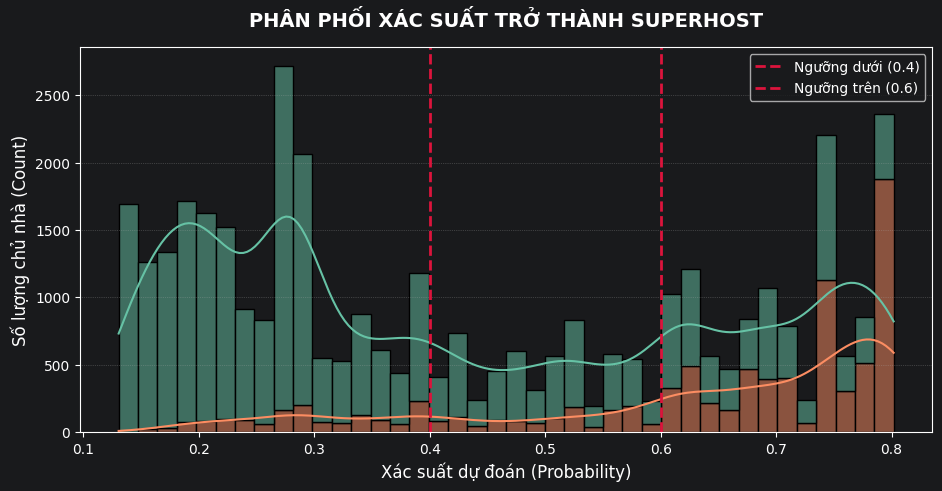

 - Tổng số chủ nhà trong tập dữ liệu: 37757 người.
 - Phát hiện 5670 chủ nhà đang nằm trong vùng 'CHẤP CHỚI' (15.02%).


In [24]:
# 1. Import các thư viện cần thiết
from pyspark.sql.functions import col, udf
from pyspark.ml.functions import vector_to_array
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Bóc tách xác suất Superhost
df_prob = rf_predictions.withColumn("prob_superhost", vector_to_array(col("probability"))[1])

# Chuyển đổi sang Pandas để vẽ biểu đồ
df_pandas = df_prob.select("prob_superhost", "label").toPandas()

# Lọc nhóm chấp chới
nhom_chap_choi = df_prob.filter((col("prob_superhost") >= 0.4) & (col("prob_superhost") <= 0.6))

print(f"Phát hiện {nhom_chap_choi.count()} chủ nhà đang ở mốc 'chấp chới' (40%-60% cơ hội).")

# 3. Vẽ biểu đồ phân phối
plt.figure(figsize=(11, 5))
# Vẽ phân phối mật độ xác suất bằng Seaborn
sns.histplot(data=df_pandas, x='prob_superhost', hue='label', kde=True, bins=40, multiple='stack', palette='Set2')
# Vẽ 2 đường giới hạn cho nhóm chấp chới
plt.axvline(x=0.4, color='crimson', linestyle='--', lw=2, label='Ngưỡng dưới (0.4)')
plt.axvline(x=0.6, color='crimson', linestyle='--', lw=2, label='Ngưỡng trên (0.6)')
plt.title('PHÂN PHỐI XÁC SUẤT TRỞ THÀNH SUPERHOST', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Xác suất dự đoán (Probability)', fontsize=12)
plt.ylabel('Số lượng chủ nhà (Count)', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.show()

# 4. Trích xuất insight số liệu thực tế
tong_so_host = df_prob.count()
ty_le_percent = (nhom_chap_choi.count() / tong_so_host) * 100

print("="*60)
print(f" - Tổng số chủ nhà trong tập dữ liệu: {tong_so_host} người.")
print(f" - Phát hiện {nhom_chap_choi.count()} chủ nhà đang nằm trong vùng 'CHẤP CHỚI' ({ty_le_percent:.2f}%).")
print("="*60)


Đang phân hoạch chủ nhà thành các nhóm chiến lược từ df_pandas...


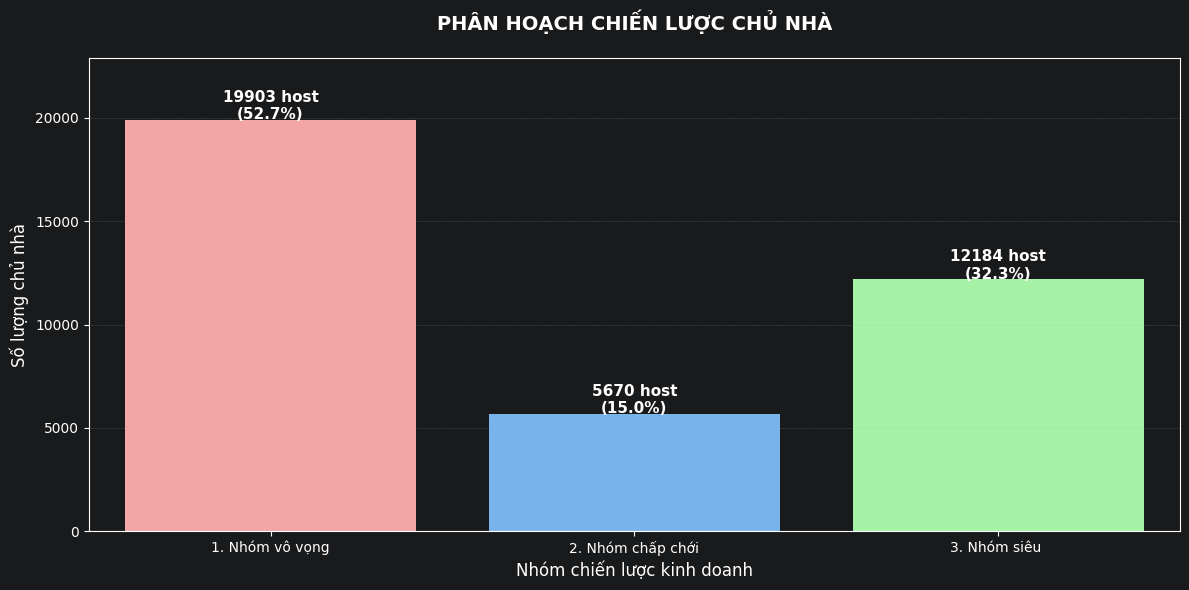

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Đảm bảo hiển thị biểu đồ trực tiếp trong Jupyter Notebook
%matplotlib inline

# Hiển thị thông báo
print("Đang phân hoạch chủ nhà thành các nhóm chiến lược từ df_pandas...")

# 1. Định nghĩa hàm phân loại dựa trên xác suất dự báo của Random Forest
def phan_loai_chien_luoc(prob):
    if prob < 0.4:
        return '1. Nhóm vô vọng'
    elif prob > 0.6:
        return '3. Nhóm siêu '
    else:
        return '2. Nhóm chấp chới'

# 2. Thay 'prob_superhost' bằng tên cột xác suất thực tế trong DataFrame
df_pandas['Strategic_Group'] = df_pandas['prob_superhost'].apply(phan_loai_chien_luoc)

# 3. Thống kê số lượng và tỷ lệ phần trăm
group_counts = df_pandas['Strategic_Group'].value_counts().sort_index()
group_percentages = df_pandas['Strategic_Group'].value_counts(normalize=True).sort_index() * 100

# 4. Vẽ biểu đồ cột trực quan hóa cấu trúc hệ thống host
plt.figure(figsize=(12, 6))
colors_group = ['#ff9999', '#66b3ff', '#99ff99']

# Cập nhật cú pháp x, y, data cho các phiên bản seaborn mới nhất
ax = sns.barplot(x=group_counts.index, y=group_counts.values, palette=colors_group, hue=group_counts.index, legend=False)

# Hiển thị số lượng và % trên đỉnh cột
for i, p in enumerate(ax.patches):
    ax.annotate(f'{group_counts.values[i]} host\n({group_percentages.values[i]:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10),
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('PHÂN HOẠCH CHIẾN LƯỢC CHỦ NHÀ', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Nhóm chiến lược kinh doanh', fontsize=12)
plt.ylabel('Số lượng chủ nhà', fontsize=12)
plt.ylim(0, max(group_counts.values) * 1.15)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


Số bản ghi cho Clustering: 188,199

 Đang tính WSSE cho K=2 đến K=8...
   K=2: WSSE = 630,814.82
   K=3: WSSE = 523,084.15
   K=4: WSSE = 431,827.98
   K=5: WSSE = 326,006.76
   K=6: WSSE = 288,202.92
   K=7: WSSE = 249,078.75
   K=8: WSSE = 230,850.78

 Đã lưu biểu đồ Elbow: elbow_plot.png


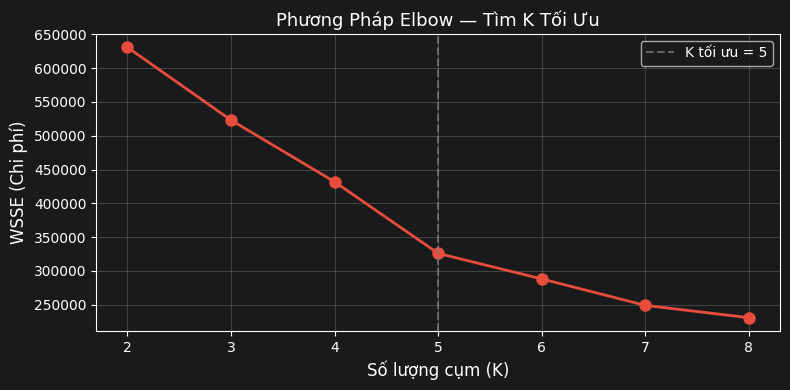

In [26]:
# Các biến dùng cho Clustering
cluster_features = ["price_usd", "host_total_listings_count", "review_scores_rating", "accommodates"]

# Tạo DataFrame clustering (lọc null)
df_cluster = df.dropna(subset=cluster_features)
print(f"Số bản ghi cho Clustering: {df_cluster.count():,}")

# Tiền xử lý riêng cho Clustering
imp_c   = Imputer(inputCols=cluster_features, outputCols=cluster_features).setStrategy("median")
asm_c   = VectorAssembler(inputCols=cluster_features, outputCol="raw_features")
scl_c   = StandardScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=True)

# Pipeline tiền xử lý (không có thuật toán)
prep_pipeline = Pipeline(stages=[imp_c, asm_c, scl_c])
prep_model    = prep_pipeline.fit(df_cluster)
df_scaled     = prep_model.transform(df_cluster)

# Phương pháp Elbow — thử K từ 2 đến 8
print("\n Đang tính WSSE cho K=2 đến K=8...")
costs = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(featuresCol="features", k=k, seed=42)
    km_model = km.fit(df_scaled)
    cost = km_model.summary.trainingCost
    costs.append(cost)
    print(f"   K={k}: WSSE = {cost:,.2f}")

# Vẽ biểu đồ Elbow
plt.figure(figsize=(8, 4))
plt.plot(list(k_range), costs, marker='o', color='#e74c3c', linewidth=2, markersize=8)
plt.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='K tối ưu = 5')
plt.xlabel("Số lượng cụm (K)", fontsize=12)
plt.ylabel("WSSE (Chi phí)", fontsize=12)
plt.title("Phương Pháp Elbow — Tìm K Tối Ưu", fontsize=13)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("elbow_plot.png", dpi=300, bbox_inches='tight')
print("\n Đã lưu biểu đồ Elbow: elbow_plot.png")
plt.show()


 Đang huấn luyện mô hình K-Means chính thức với K = 5...
   Điểm Silhouette Score: 0.6608

 Đang khởi tạo sơ đồ trực quan hóa kết quả K-Means...
 Đã lưu biểu đồ kết quả: kmeans_result_plot.png


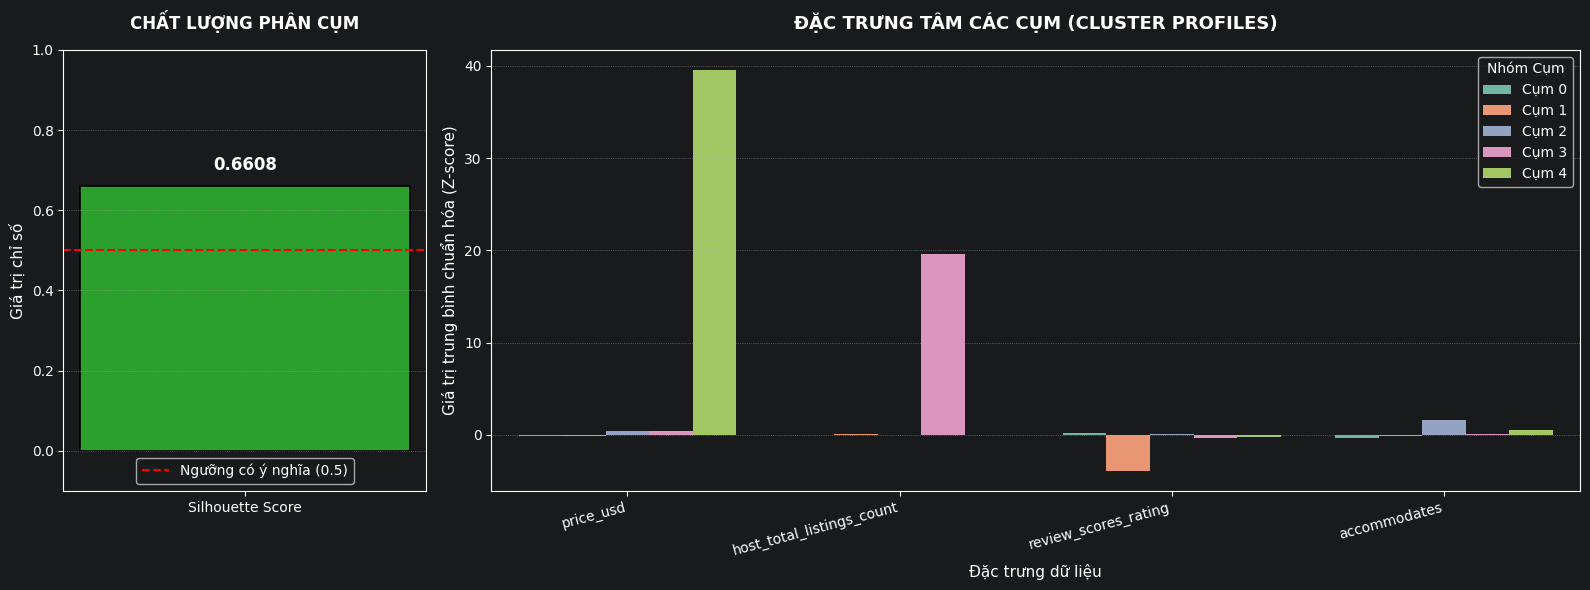

In [27]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# =====================================================================
# BƯỚC 1: HUẤN LUYỆN MÔ HÌNH
# =====================================================================
best_k = 5

# Khởi tạo thuật toán KMeans
kmeans_algo = KMeans(featuresCol="features", predictionCol="prediction", k=best_k, seed=42)

# Gộp các bước tiền xử lý cũ và KMeans vào một Pipeline duy nhất
cluster_pipeline = Pipeline(stages=[imp_c, asm_c, scl_c, kmeans_algo])

print(f"\n Đang huấn luyện mô hình K-Means chính thức với K = {best_k}...")
cluster_model = cluster_pipeline.fit(df_cluster)

# Dự đoán cụm và tính điểm Silhouette
predictions = cluster_model.transform(df_cluster)
evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette", distanceMeasure="squaredEuclidean")
silhouette = evaluator.evaluate(predictions)
print(f"   Điểm Silhouette Score: {silhouette:.4f}")


# =====================================================================
# BƯỚC 2: TRÍCH XUẤT TỌA ĐỘ TÂM CỤM & CHUYỂN ĐỔI DỮ LIỆU
# =====================================================================
# Lấy danh sách tên đặc trưng gốc từ VectorAssembler (stage số 2: index 1)
assembler_stage = cluster_model.stages[1]
feature_names = list(assembler_stage.getInputCols())

# Lấy tọa độ tâm cụm từ KMeans
kmeans_stage = cluster_model.stages[-1]
centers = kmeans_stage.clusterCenters()

# Chuyển đổi sang Pandas DataFrame để chuẩn bị vẽ đồ thị
df_centers = pd.DataFrame(centers, columns=feature_names)
df_centers.index.name = 'Cluster'
df_centers = df_centers.reset_index()

# Biến đổi cấu trúc bảng từ dạng ngang sang dọc (Melt) để vẽ nhóm cột
df_centers_melt = df_centers.melt(id_vars='Cluster', var_name='Dac_Trung', value_name='Gia_Tri_Tam')
df_centers_melt['Cluster_Label'] = df_centers_melt['Cluster'].apply(lambda x: f'Cụm {x}')


# =====================================================================
# BƯỚC 3: KHỞI TẠO VÀ VẼ ĐỒ THỊ TRỰC QUAN HÓA KẾT QUẢ
# =====================================================================
print("\n Đang khởi tạo sơ đồ trực quan hóa kết quả K-Means...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 3]})

# --- ĐỒ THỊ 1: THANH ĐO CHẤT LƯỢNG PHÂN CỤM (SILHOUETTE) ---
ax_score = axes[0]
color_score = '#2ca02c' if silhouette >= 0.5 else '#ff7f0e'
ax_score.bar(['Silhouette Score'], [silhouette], color=color_score, width=0.4, edgecolor='black', linewidth=1.2)
ax_score.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Ngưỡng có ý nghĩa (0.5)')

ax_score.set_ylim([-0.1, 1.0])
ax_score.set_ylabel('Giá trị chỉ số', fontsize=11)
ax_score.set_title('CHẤT LƯỢNG PHÂN CỤM', fontsize=12, fontweight='bold', pad=15)
ax_score.text(0, silhouette + 0.03, f'{silhouette:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax_score.legend(loc='lower center')
ax_score.grid(axis='y', linestyle=':', alpha=0.7)

# --- ĐỒ THỊ 2: ĐẶC TRƯNG CÁC CỤM---
ax_profile = axes[1]
sns.barplot(
    data=df_centers_melt,
    x='Dac_Trung',
    y='Gia_Tri_Tam',
    hue='Cluster_Label',
    ax=ax_profile,
    palette='Set2'
)

ax_profile.set_title('ĐẶC TRƯNG TÂM CÁC CỤM (CLUSTER PROFILES)', fontsize=13, fontweight='bold', pad=15)
ax_profile.set_xlabel('Đặc trưng dữ liệu', fontsize=11)
ax_profile.set_ylabel('Giá trị trung bình chuẩn hóa (Z-score)', fontsize=11)
ax_profile.legend(title='Nhóm Cụm', loc='upper right')
ax_profile.grid(axis='y', linestyle=':', alpha=0.7)

# Xoay nhãn trục x để tránh đè chữ
plt.setp(ax_profile.get_xticklabels(), rotation=15, ha='right')

# Tự động điều chỉnh khoảng cách và hiển thị
plt.tight_layout()
plt.savefig("kmeans_result_plot.png", dpi=300, bbox_inches='tight')
print(" Đã lưu biểu đồ kết quả: kmeans_result_plot.png")
plt.show()


 Đang chuyển đổi dữ liệu và tính toán Silhouette Plot...


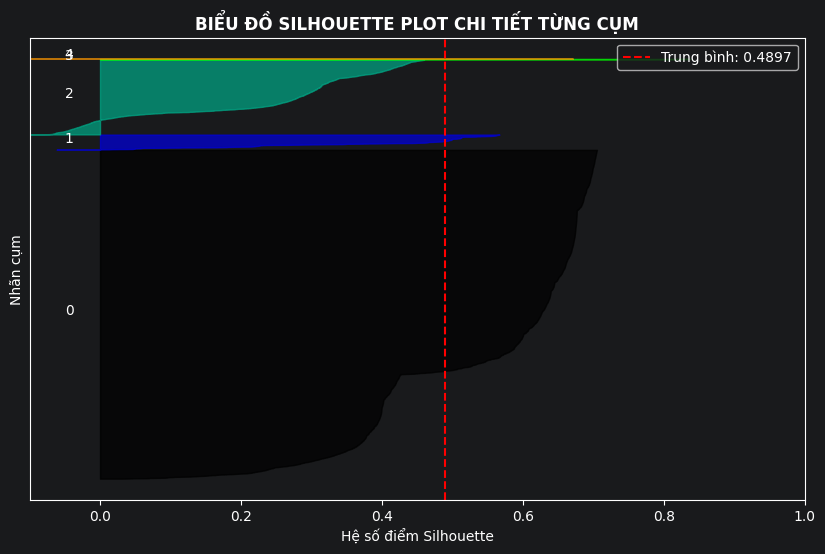

In [28]:
import matplotlib.cm as cm
import numpy as np
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt

# Gọi lại hàm transform từ mô hình đã huấn luyện (cluster_model) để tạo predictions
predictions = cluster_model.transform(df_cluster)


# =====================================================================
# 2. TRÍCH XUẤT DỮ LIỆU VÀ VẼ SILHOUETTE PLOT
# =====================================================================
print(" Đang chuyển đổi dữ liệu và tính toán Silhouette Plot...")

# Chuyển đổi sang Pandas (Lấy mẫu 10% dữ liệu để tránh quá tải RAM)
pandas_df = predictions.select("features", "prediction").sample(fraction=0.1, seed=42).toPandas()

# Chuyển đổi cột vector đặc trưng sang mảng numpy (yêu cầu của sklearn)
X = np.array(pandas_df['features'].tolist())
cluster_labels = pandas_df['prediction'].values

# Tính toán Silhouette Score và Silhouette Samples
silhouette_avg = silhouette_score(X, cluster_labels)
sample_silhouette_values = silhouette_samples(X, cluster_labels)

# Thiết lập vẽ đồ thị Silhouette
fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for i in range(best_k):
    # Lấy điểm Silhouette của các điểm dữ liệu thuộc cụm i và sắp xếp chúng
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    # Chọn màu cho từng cụm
    color = cm.nipy_spectral(float(i) / best_k)

    # Vẽ các dải Silhouette (Fill)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, ith_cluster_silhouette_values,
                     facecolor=color, edgecolor=color, alpha=0.7)

    # Đánh nhãn cụm ở giữa đồ thị
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Cập nhật y_lower cho cụm tiếp theo
    y_lower = y_upper + 10

ax.set_title("BIỂU ĐỒ SILHOUETTE PLOT CHI TIẾT TỪNG CỤM", fontsize=12, fontweight='bold')
ax.set_xlabel("Hệ số điểm Silhouette")
ax.set_ylabel("Nhãn cụm")

# Vẽ đường trung bình hệ số Silhouette toàn cục
ax.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"Trung bình: {silhouette_avg:.4f}")
ax.set_yticks([])  # Xóa các nhãn trên trục Y
ax.set_xlim([-0.1, 1])
ax.legend(loc="upper right")
plt.show()


In [29]:
from pyspark.sql.functions import count, avg, col, round as spark_round

# 1. Đảm bảo tên biến đồng bộ với dữ liệu đã dự đoán từ mô hình K-Means
cluster_preds = predictions  # Gán từ kết quả 'predictions' ở bước huấn luyện trước đó

# 2. Tính tổng số bản ghi để tính tỷ lệ % quy mô của từng cụm
total_records = df_cluster.count()

print("\n CHÂN DUNG CÁC NHÓM CHỦ NHÀ")

# 3. Gom nhóm và tính toán các chỉ số thống kê trên đơn vị gốc
cluster_profile = cluster_preds.groupBy("prediction").agg(  # Mặc định KMeans trong PySpark đặt tên cột dự đoán là 'prediction'
    count("*").alias("so_luong"),
    spark_round((count("*") / total_records) * 100, 2).alias("ty_le_phan_tram"),
    spark_round(avg("price_usd"), 2).alias("gia_tb"),
    spark_round(avg("host_total_listings_count"), 2).alias("so_listing_tb"),
    spark_round(avg("review_scores_rating"), 2).alias("diem_danh_gia_tb"), # Đổi sang 2 chữ số thập phân cho dễ đọc
    spark_round(avg("accommodates"), 2).alias("suc_chua_tb")
).withColumnRenamed("prediction", "cluster") \
 .orderBy("cluster")

# 4. Hiển thị bảng kết quả dạng text gọn gàng
cluster_profile.show(truncate=False)


 CHÂN DUNG CÁC NHÓM CHỦ NHÀ
+-------+--------+---------------+-------+-------------+----------------+-----------+
|cluster|so_luong|ty_le_phan_tram|gia_tb |so_listing_tb|diem_danh_gia_tb|suc_chua_tb|
+-------+--------+---------------+-------+-------------+----------------+-----------+
|0      |146943  |78.08          |77.44  |7.23         |94.88           |2.57       |
|1      |6742    |3.58           |79.35  |13.69        |54.14           |3.07       |
|2      |34199   |18.17          |205.19 |10.49        |94.83           |6.71       |
|3      |246     |0.13           |226.58 |1265.31      |90.33           |3.56       |
|4      |69      |0.04           |10516.3|5.57         |90.58           |4.39       |
+-------+--------+---------------+-------+-------------+----------------+-----------+



In [31]:
# MODEL_PATH = "hdfs://master-node:9000/AirbnbData/models/rf_superhost"
MODEL_PATH = "streaming/models/rf_superhost"
rf_model.write().overwrite().save(MODEL_PATH)
print("Đã lưu mô hình:", MODEL_PATH)

Đã lưu mô hình: streaming/models/rf_superhost
